In [1]:
!pip install -q datasets nltk

In [2]:
import os, math, random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import nltk
from collections import Counter, defaultdict

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

os.makedirs("figures", exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


In [3]:
from datasets import load_dataset

print("WikiText-2 yükleniyor...")
wt2 = load_dataset("wikitext", "wikitext-2-raw-v1")

def preprocess(text):
    """Metni temizle, tokenize et."""
    lines = []
    for line in text:
        line = line.strip()
        if line and not line.startswith("="):   # başlıkları atla
            tokens = line.lower().split()
            if tokens:
                lines.append(tokens)
    return lines

train_sents = preprocess(wt2["train"]["text"])
val_sents   = preprocess(wt2["validation"]["text"])
test_sents  = preprocess(wt2["test"]["text"])

# Düz token listeleri (N-gram için)
train_tokens = [tok for sent in train_sents for tok in sent]
val_tokens   = [tok for sent in val_sents   for tok in sent]
test_tokens  = [tok for sent in test_sents  for tok in sent]

print(f"Train: {len(train_sents):,} cümle | {len(train_tokens):,} token")
print(f"Val  : {len(val_sents):,} cümle | {len(val_tokens):,} token")
print(f"Test : {len(test_sents):,} cümle | {len(test_tokens):,} token")

# Vocabulary
counter = Counter(train_tokens)
VOCAB_SIZE = 10000
vocab_words = ["<pad>", "<unk>", "<sos>", "<eos>"] + \
              [w for w, _ in counter.most_common(VOCAB_SIZE - 4)]
word2idx = {w: i for i, w in enumerate(vocab_words)}
idx2word = {i: w for w, i in word2idx.items()}
UNK_IDX  = word2idx["<unk>"]

def encode_sent(tokens):
    return [word2idx.get(t, UNK_IDX) for t in tokens]

print(f"Vocabulary boyutu: {len(word2idx):,}")

WikiText-2 yükleniyor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Train: 17,556 cümle | 2,007,146 token
Val  : 1,841 cümle | 209,338 token
Test : 2,183 cümle | 235,845 token
Vocabulary boyutu: 10,000


In [4]:
print("\n" + "█"*60)
print("  MODEL 1 & 2: Bigram ve Trigram (Laplace Smoothing)")
print("█"*60)

# ── N-gram sayımları ──────────────────────────────────────────────────────────
def build_ngram_counts(tokens, n):
    counts = defaultdict(Counter)
    for i in range(len(tokens) - n + 1):
        context = tuple(tokens[i:i+n-1])
        word    = tokens[i+n-1]
        counts[context][word] += 1
    return counts

print("Bigram sayımları yapılıyor...")
bigram_counts  = build_ngram_counts(train_tokens, 2)
unigram_counts = Counter(train_tokens)
total_tokens   = len(train_tokens)
V = len(word2idx)   # vocabulary boyutu (Laplace için)

print("Trigram sayımları yapılıyor...")
trigram_counts = build_ngram_counts(train_tokens, 3)
bigram_total   = {ctx: sum(cnts.values()) for ctx, cnts in bigram_counts.items()}


# ── Perplexity Hesaplama ──────────────────────────────────────────────────────
def bigram_log_prob(context_word, word, alpha=1.0):
    """Laplace smoothed bigram log olasılığı."""
    ctx   = (context_word,)
    count = bigram_counts[ctx][word] + alpha
    total = sum(bigram_counts[ctx].values()) + alpha * V
    return math.log(count / total)

def trigram_log_prob(w1, w2, word, alpha=1.0):
    """Laplace smoothed trigram log olasılığı."""
    ctx   = (w1, w2)
    count = trigram_counts[ctx][word] + alpha
    total = sum(trigram_counts[ctx].values()) + alpha * V
    return math.log(count / total)

def compute_ngram_perplexity(tokens, model="bigram", alpha=1.0):
    """Test token listesi üzerinde perplexity hesapla."""
    log_prob_sum = 0.0
    N = 0
    if model == "bigram":
        for i in range(1, len(tokens)):
            log_prob_sum += bigram_log_prob(tokens[i-1], tokens[i], alpha)
            N += 1
    elif model == "trigram":
        for i in range(2, len(tokens)):
            log_prob_sum += trigram_log_prob(tokens[i-2], tokens[i-1], tokens[i], alpha)
            N += 1
    avg_log_prob = log_prob_sum / N
    return math.exp(-avg_log_prob)


print("\nPerplexity hesaplanıyor...")
bigram_val_ppl  = compute_ngram_perplexity(val_tokens,  "bigram")
bigram_test_ppl = compute_ngram_perplexity(test_tokens, "bigram")
trigram_val_ppl  = compute_ngram_perplexity(val_tokens,  "trigram")
trigram_test_ppl = compute_ngram_perplexity(test_tokens, "trigram")

print(f"\n{'='*50}")
print(f"  Bigram  — Val PPL: {bigram_val_ppl:.2f}  | Test PPL: {bigram_test_ppl:.2f}")
print(f"  Trigram — Val PPL: {trigram_val_ppl:.2f} | Test PPL: {trigram_test_ppl:.2f}")
print(f"{'='*50}")


# ── Metin Üretimi (N-gram) ────────────────────────────────────────────────────
def ngram_generate(seed_word, model="bigram", max_words=20, temperature=1.0):
    """N-gram ile metin üret."""
    generated = [seed_word]
    for _ in range(max_words):
        if model == "bigram":
            ctx = (generated[-1],)
            candidates = bigram_counts.get(ctx, {})
        else:
            if len(generated) < 2:
                ctx = (generated[-1],)
                candidates = bigram_counts.get(ctx, {})
            else:
                ctx = (generated[-2], generated[-1])
                candidates = trigram_counts.get(ctx, {})

        if not candidates:
            break
        words  = list(candidates.keys())
        counts = np.array(list(candidates.values()), dtype=float)
        counts = counts ** (1.0 / temperature)
        probs  = counts / counts.sum()
        next_w = np.random.choice(words, p=probs)
        generated.append(next_w)
        if next_w in [".", "!", "?"]:
            break
    return " ".join(generated)

print("\n--- Bigram Üretim Örnekleri ---")
for seed in ["the", "in", "he"]:
    print(f"  '{seed}' → {ngram_generate(seed, 'bigram')}")

print("\n--- Trigram Üretim Örnekleri ---")
for seed in ["the", "in", "he"]:
    print(f"  '{seed}' → {ngram_generate(seed, 'trigram')}")


████████████████████████████████████████████████████████████
  MODEL 1 & 2: Bigram ve Trigram (Laplace Smoothing)
████████████████████████████████████████████████████████████
Bigram sayımları yapılıyor...
Trigram sayımları yapılıyor...

Perplexity hesaplanıyor...

  Bigram  — Val PPL: 1473.88  | Test PPL: 1504.73
  Trigram — Val PPL: 5287.55 | Test PPL: 5341.04

--- Bigram Üretim Örnekleri ---
  'the' → the canadian / soul of the local tradition by dave thomas 's misdirected martyrdom of the 1st , that " a
  'in' → in other genera diversified near @-@ generated by and attempts to discover that the catechisms in finkelstein tenure , mario bros.
  'he' → he was able to mogadishu .

--- Trigram Üretim Örnekleri ---
  'the' → the junta to become the show received a message back for more than one cult center , which travels to sarasaland
  'in' → in various underground venues .
  'he' → he nails it " her two elder pitman children received their offerings in bodies of the 2004 mtv video mus


████████████████████████████████████████████████████████████
  MODEL 3: LSTM Language Model
████████████████████████████████████████████████████████████
LSTM LM parametreleri: 9,332,496

LSTM LM eğitimi başlıyor...
Epoch  1/15 | Train PPL:  394.69 | Val PPL:  201.13 | LR: 20.0000
Epoch  2/15 | Train PPL:  187.85 | Val PPL:  141.51 | LR: 20.0000
Epoch  3/15 | Train PPL:  140.80 | Val PPL:  115.48 | LR: 20.0000
Epoch  4/15 | Train PPL:  118.53 | Val PPL:  101.79 | LR: 20.0000
Epoch  5/15 | Train PPL:  105.58 | Val PPL:   94.41 | LR: 20.0000
Epoch  6/15 | Train PPL:   96.57 | Val PPL:   88.32 | LR: 20.0000
Epoch  7/15 | Train PPL:   90.15 | Val PPL:   85.18 | LR: 20.0000
Epoch  8/15 | Train PPL:   85.29 | Val PPL:   83.30 | LR: 20.0000
Epoch  9/15 | Train PPL:   81.34 | Val PPL:   81.13 | LR: 20.0000
Epoch 10/15 | Train PPL:   78.27 | Val PPL:   78.98 | LR: 10.0000
Epoch 11/15 | Train PPL:   71.27 | Val PPL:   74.30 | LR: 5.0000
Epoch 12/15 | Train PPL:   67.78 | Val PPL:   72.45 | LR: 2

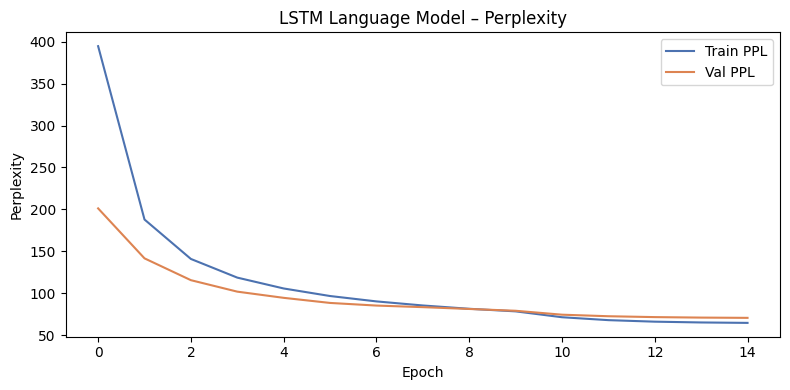


--- LSTM Üretim Örnekleri (temperature=0.8) ---
  'the' → the <unk> <unk> and the <unk> of the <unk> .
  'in the' → in the <unk> <unk> <unk> .
  'he was' → he was the only choice of the history of the city .


In [6]:
print("\n" + "█"*60)
print("  MODEL 3: LSTM Language Model")
print("█"*60)

# ── Hyperparameters ───────────────────────────────────────────────────────────
EMB_DIM    = 512
HID_DIM    = 512
NUM_LAYERS = 2
DROPOUT    = 0.5
BPTT       = 35      # Backprop Through Time pencere uzunluğu
BATCH_SIZE = 64
EPOCHS_LM  = 15
LR_LM      = 20.0   # SGD için yüksek LR (standart LM pratiği)
CLIP       = 0.25


# ── Dataset ──────────────────────────────────────────────────────────────────
def tokens_to_ids(tokens):
    return torch.tensor([word2idx.get(t, UNK_IDX) for t in tokens],
                        dtype=torch.long)

def batchify(data, batch_size):
    """Veriyi batch_size sütununa böl."""
    n_batch = data.size(0) // batch_size
    data = data[:n_batch * batch_size]
    return data.view(batch_size, -1).t().contiguous()   # (seq_len, batch)

train_ids = batchify(tokens_to_ids(train_tokens), BATCH_SIZE).to(DEVICE)
val_ids   = batchify(tokens_to_ids(val_tokens),   10).to(DEVICE)
test_ids  = batchify(tokens_to_ids(test_tokens),  10).to(DEVICE)

def get_batch(source, i, bptt=BPTT):
    seq_len = min(bptt, source.size(0) - 1 - i)
    data   = source[i:i+seq_len]
    target = source[i+1:i+seq_len+1].reshape(-1)
    return data, target


# ── LSTM Model ────────────────────────────────────────────────────────────────
class LSTMLanguageModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.dropout   = nn.Dropout(dropout)
        self.lstm = nn.LSTM(emb_dim, hid_dim, num_layers=num_layers,
                            dropout=dropout, batch_first=False)
        self.fc   = nn.Linear(hid_dim, vocab_size)
        # Weight tying: embedding ve output ağırlıklarını paylaş
        self.fc.weight = self.embedding.weight
        self.init_weights()

    def init_weights(self):
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x, hidden):
        emb = self.dropout(self.embedding(x))
        out, hidden = self.lstm(emb, hidden)
        out = self.dropout(out)
        logits = self.fc(out.reshape(-1, out.size(2)))
        return logits, hidden

    def init_hidden(self, batch_size):
        weight = next(self.parameters())
        return (weight.new_zeros(NUM_LAYERS, batch_size, HID_DIM),
                weight.new_zeros(NUM_LAYERS, batch_size, HID_DIM))

    def detach_hidden(self, hidden):
        return tuple(h.detach() for h in hidden)


lstm_lm = LSTMLanguageModel(len(word2idx), EMB_DIM, HID_DIM,
                              NUM_LAYERS, DROPOUT).to(DEVICE)
optimizer_lm = torch.optim.SGD(lstm_lm.parameters(), lr=LR_LM)
criterion_lm = nn.CrossEntropyLoss()

print(f"LSTM LM parametreleri: {sum(p.numel() for p in lstm_lm.parameters()):,}")


# ── Eğitim Döngüsü ───────────────────────────────────────────────────────────
def train_lm(model, data, optimizer, criterion, bptt, clip, lr):
    model.train()
    total_loss = 0
    hidden = model.init_hidden(BATCH_SIZE)
    for i in range(0, data.size(0) - 1, bptt):
        x, y = get_batch(data, i, bptt)
        hidden = model.detach_hidden(hidden)
        optimizer.zero_grad()
        output, hidden = model(x, hidden)
        loss = criterion(output, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / (data.size(0) - 1)


def eval_lm(model, data, criterion, bptt):
    model.eval()
    total_loss = 0
    hidden = model.init_hidden(10)   # val/test batch size = 10
    with torch.no_grad():
        for i in range(0, data.size(0) - 1, bptt):
            x, y = get_batch(data, i, bptt)
            output, hidden = model(x, hidden)
            hidden = model.detach_hidden(hidden)
            total_loss += criterion(output, y).item() * x.size(0)
    return total_loss / (data.size(0) - 1)


print("\nLSTM LM eğitimi başlıyor...")
history_lm = {"train_ppl": [], "val_ppl": []}
best_val_ppl = float("inf")
lr = LR_LM

for epoch in range(1, EPOCHS_LM + 1):
    tr_loss = train_lm(lstm_lm, train_ids, optimizer_lm,
                       criterion_lm, BPTT, CLIP, lr)
    vl_loss = eval_lm(lstm_lm, val_ids, criterion_lm, BPTT)

    tr_ppl = math.exp(tr_loss)
    vl_ppl = math.exp(vl_loss)
    history_lm["train_ppl"].append(tr_ppl)
    history_lm["val_ppl"].append(vl_ppl)

    # Learning rate decay (epoch >= 10'dan sonra her epoch yarıya indir)
    if epoch >= 10:
        lr /= 2.0
        for param_group in optimizer_lm.param_groups:
            param_group["lr"] = lr

    if vl_ppl < best_val_ppl:
        best_val_ppl = vl_ppl
        torch.save(lstm_lm.state_dict(), "best_lstm_lm.pt")

    print(f"Epoch {epoch:2d}/{EPOCHS_LM} | "
          f"Train PPL: {tr_ppl:7.2f} | Val PPL: {vl_ppl:7.2f} | LR: {lr:.4f}")

# Test perplexity
lstm_lm.load_state_dict(torch.load("best_lstm_lm.pt"))
test_loss = eval_lm(lstm_lm, test_ids, criterion_lm, BPTT)
lstm_test_ppl = math.exp(test_loss)
lstm_val_ppl  = best_val_ppl
print(f"\nLSTM — Best Val PPL: {lstm_val_ppl:.2f} | Test PPL: {lstm_test_ppl:.2f}")

# Eğitim eğrisi
plt.figure(figsize=(8, 4))
plt.plot(history_lm["train_ppl"], label="Train PPL", color="#4C72B0")
plt.plot(history_lm["val_ppl"],   label="Val PPL",   color="#DD8452")
plt.title("LSTM Language Model – Perplexity")
plt.xlabel("Epoch"); plt.ylabel("Perplexity")
plt.legend(); plt.tight_layout()
plt.savefig("figures/q5_lstm_training.png", dpi=150)
plt.show()


# ── LSTM Metin Üretimi ────────────────────────────────────────────────────────
def lstm_generate(model, seed_text, max_words=30, temperature=1.0):
    model.eval()
    tokens  = seed_text.lower().split()
    ids     = [word2idx.get(t, UNK_IDX) for t in tokens]
    input_t = torch.tensor(ids, dtype=torch.long).unsqueeze(1).to(DEVICE)
    hidden  = model.init_hidden(1)

    generated = list(tokens)
    with torch.no_grad():
        for inp in input_t[:-1]:
            _, hidden = model(inp.unsqueeze(0), hidden)

        inp = input_t[-1]
        for _ in range(max_words):
            output, hidden = model(inp.unsqueeze(0), hidden)
            logits = output.squeeze() / temperature
            probs  = torch.softmax(logits, dim=0).cpu().numpy()
            next_id = np.random.choice(len(probs), p=probs)
            next_w  = idx2word.get(next_id, "<unk>")
            generated.append(next_w)
            inp = torch.tensor([next_id], dtype=torch.long).to(DEVICE)
            if next_w in [".", "!", "?"]:
                break
    return " ".join(generated)


print("\n--- LSTM Üretim Örnekleri (temperature=0.8) ---")
for seed in ["the", "in the", "he was"]:
    print(f"  '{seed}' → {lstm_generate(lstm_lm, seed, temperature=0.8)}")



═══════════════════════════════════════════════════════
  GENEL SONUÇLAR
═══════════════════════════════════════════════════════
  Model              Val PPL   Test PPL
-------------------------------------------------------
  Bigram             1473.88    1504.73
  Trigram            5287.55    5341.04
  LSTM                 70.52      66.77
═══════════════════════════════════════════════════════


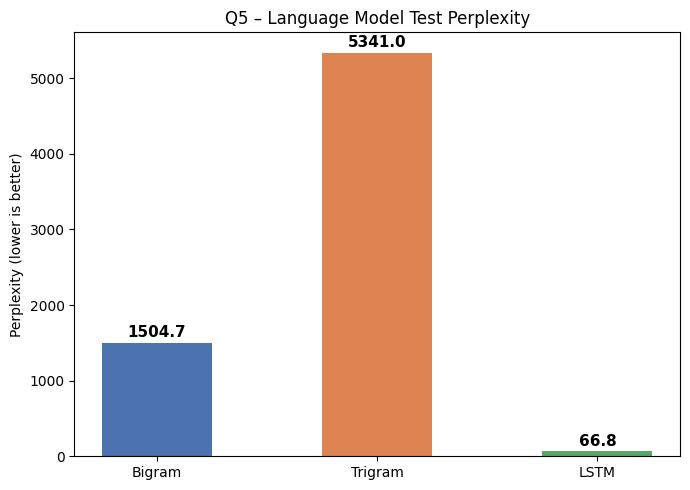


✅ Q5 tamamlandı!


In [7]:
print("\n" + "═"*55)
print("  GENEL SONUÇLAR")
print("═"*55)
print(f"  {'Model':<15} {'Val PPL':>10} {'Test PPL':>10}")
print("-"*55)
print(f"  {'Bigram':<15} {bigram_val_ppl:>10.2f} {bigram_test_ppl:>10.2f}")
print(f"  {'Trigram':<15} {trigram_val_ppl:>10.2f} {trigram_test_ppl:>10.2f}")
print(f"  {'LSTM':<15} {lstm_val_ppl:>10.2f} {lstm_test_ppl:>10.2f}")
print("═"*55)

# Bar chart — Test PPL
models   = ["Bigram", "Trigram", "LSTM"]
test_ppls = [bigram_test_ppl, trigram_test_ppl, lstm_test_ppl]
colors   = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(models, test_ppls, color=colors, width=0.5)
ax.set_ylabel("Perplexity (lower is better)")
ax.set_title("Q5 – Language Model Test Perplexity")
for bar, val in zip(bars, test_ppls):
    ax.annotate(f"{val:.1f}",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/q5_comparison.png", dpi=150)
plt.show()

print("\n✅ Q5 tamamlandı!")